# The true evaluation of model robustness: bootstrapping


Total number of features: 30

Train period: 1990-02-16 to 2019-12-30
Test period : 2020-01-02 to 2026-04-01
Train shape : (7523, 30)
Test shape  : (1592, 30)

Performance summary
sample  n_obs      auc     gini       ks
 train   7523 0.561766 0.123532 0.091344
  test   1592 0.549023 0.098045 0.083886


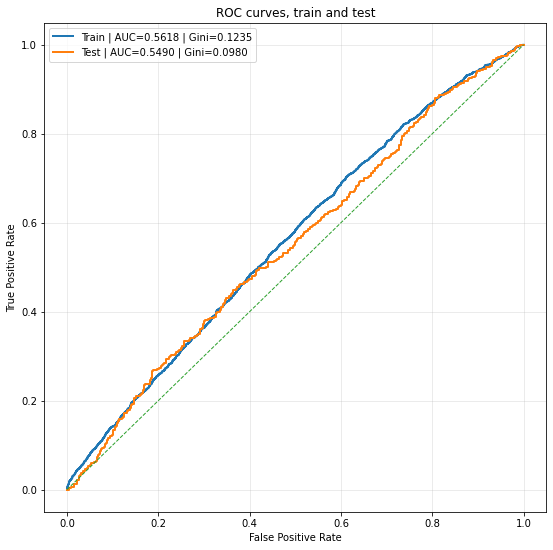


Top positive coefficients
      feature  coefficient
 vol_22_lag_2     0.291407
  vol_5_lag_3     0.230200
 vol_22_lag_5     0.198501
 vol_10_lag_4     0.187820
  vol_5_lag_7     0.170327
 vol_10_lag_9     0.122591
  vol_5_lag_4     0.122245
  vol_5_lag_8     0.119068
  vol_5_lag_2     0.102438
vol_22_lag_10     0.095361

Top negative coefficients
      feature  coefficient
 vol_10_lag_3    -0.076008
  vol_5_lag_9    -0.098052
 vol_10_lag_1    -0.125133
 vol_10_lag_5    -0.130597
  vol_5_lag_1    -0.140182
vol_10_lag_10    -0.140826
 vol_22_lag_6    -0.181077
 vol_22_lag_4    -0.209895
 vol_22_lag_3    -0.245013
 vol_10_lag_2    -0.405688


In [ ]:
# ============================================================
# Bootstrapping example with a VIX directional model with Logistic Regression
# ============================================================
# Objective:
# Predict whether the next 5 trading day return of the VIX will be positive.
#
# Target:
#   1 -> if the future 5-day return is positive
#   0 -> otherwise
#
# Features:
#   Rolling volatility of daily returns for windows:
#   - 5 days
#   - 10 days
#   - 22 days
#
#   For each rolling volatility, use the first 10 lags.
#   Total features = 3 windows * 10 lags = 30
#
# Split:
#   Train: all observations up to and including 2019-12-31
#   Test : all observations from 2020-01-01 onward
#
# Model:
#   Standard Logistic Regression
#
# Evaluation:
#   - AUC
#   - Gini = 2*AUC - 1
#   - KS
#   - ROC curves
#   - Bootstrap by resampling training rows with replacement
# ============================================================


# =========================
# 1. Imports
# =========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tvDatafeed import TvDatafeed, Interval

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

from tqdm import tqdm


# =========================
# 2. Configuration
# =========================
SYMBOL = "VIX"
EXCHANGE = "CBOE"
INTERVAL = Interval.in_daily
N_BARS = 10000

TARGET_HORIZON = 5
VOL_WINDOWS = [5, 10, 22]
N_LAGS = 10

TRAIN_END = "2019-12-31"
TEST_START = "2020-01-01"

BOOTSTRAP_SAMPLES = 1000
BOOTSTRAP_TRAIN_SIZE = None
# If None, the bootstrap sample size will be equal to the number of rows in the training set.
# If you want a custom size, for example 2000, just set:
# BOOTSTRAP_TRAIN_SIZE = 2000

RANDOM_STATE = 42


# =========================
# 3. Helper functions
# =========================
def compute_auc_gini(y_true, y_score):
    """
    Compute AUC and Gini.

    Gini = 2 * AUC - 1
    """
    auc = roc_auc_score(y_true, y_score)
    gini = 2 * auc - 1
    return auc, gini


def compute_ks(y_true, y_score):
    """
    Compute KS statistic from the ROC curve.

    KS = max(TPR - FPR)
    """
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ks = np.max(tpr - fpr)
    return ks


def fit_logistic_regression(X_train, y_train, random_state=42):
    """
    Fit a standard logistic regression pipeline with scaling.
    No cross-validation, no parameter tuning.
    """
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    model.fit(X_train, y_train)
    return model


def plot_combined_roc(y_train, train_proba, y_test, test_proba):
    """
    Plot train and test ROC curves in a single chart.
    """
    train_auc, train_gini = compute_auc_gini(y_train, train_proba)
    test_auc, test_gini = compute_auc_gini(y_test, test_proba)

    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

    plt.figure(figsize=(9, 9))
    plt.plot(
        fpr_train, tpr_train, linewidth=2,
        label=f"Train | AUC={train_auc:.4f} | Gini={train_gini:.4f}"
    )
    plt.plot(
        fpr_test, tpr_test, linewidth=2,
        label=f"Test | AUC={test_auc:.4f} | Gini={test_gini:.4f}"
    )
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves, train and test")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def summarize_bootstrap_metric(values, metric_name):
    """
    Print summary statistics for a bootstrap metric distribution.
    """
    print(f"\nBootstrap summary for {metric_name}")
    print("-" * 45)
    print(f"Mean      : {np.mean(values):.6f}")
    print(f"Std       : {np.std(values, ddof=1):.6f}")
    print(f"Median    : {np.median(values):.6f}")
    print(f"2.5%      : {np.percentile(values, 2.5):.6f}")
    print(f"5.0%      : {np.percentile(values, 5.0):.6f}")
    print(f"95.0%     : {np.percentile(values, 95.0):.6f}")
    print(f"97.5%     : {np.percentile(values, 97.5):.6f}")


def plot_bootstrap_hist(metric_values, observed_value, metric_name):
    """
    Plot the bootstrap distribution of a metric and mark the observed value.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(metric_values, bins=40, edgecolor="black")
    plt.axvline(
        observed_value,
        linestyle="--",
        linewidth=2,
        label=f"Observed {metric_name} = {observed_value:.4f}"
    )
    plt.xlabel(metric_name)
    plt.ylabel("Frequency")
    plt.title(f"Bootstrap distribution of test {metric_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def bootstrap_training_rows(
    train_df,
    test_df,
    feature_cols,
    n_bootstrap=1000,
    bootstrap_train_size=None,
    random_state=42
):
    """
    Bootstrap the training set by resampling individual training rows with replacement.

    Procedure:
    1. Keep the test set fixed.
    2. Sample rows from the training set with replacement.
    3. Retrain the logistic regression on the bootstrap training sample.
    4. Score the fixed test set.
    5. Store test AUC, Gini, and KS.

    Parameters
    ----------
    train_df : pandas.DataFrame
        Training dataset with features and target.
    test_df : pandas.DataFrame
        Fixed out-of-sample test dataset with features and target.
    feature_cols : list
        List of feature column names.
    n_bootstrap : int
        Number of bootstrap repetitions.
    bootstrap_train_size : int or None
        Number of rows to sample in each bootstrap iteration.
        If None, use the full training sample size.
    random_state : int
        Random seed.

    Returns
    -------
    pandas.DataFrame
        DataFrame with bootstrap metrics.
    """
    rng = np.random.default_rng(random_state)

    n_train = len(train_df)
    sample_size = n_train if bootstrap_train_size is None else bootstrap_train_size

    X_test = test_df[feature_cols]
    y_test = test_df["target"].values

    results = []

    for b in tqdm(range(n_bootstrap), desc="Bootstrapping training rows"):
        sampled_idx = rng.integers(0, n_train, size=sample_size)
        boot_train_df = train_df.iloc[sampled_idx].copy()

        X_boot = boot_train_df[feature_cols]
        y_boot = boot_train_df["target"]

        if len(np.unique(y_boot)) < 2:
            continue

        try:
            model_boot = fit_logistic_regression(
                X_boot,
                y_boot,
                random_state=random_state + b
            )

            test_proba_boot = model_boot.predict_proba(X_test)[:, 1]

            auc_boot, gini_boot = compute_auc_gini(y_test, test_proba_boot)
            ks_boot = compute_ks(y_test, test_proba_boot)

            results.append({
                "bootstrap_id": b + 1,
                "auc_test": auc_boot,
                "gini_test": gini_boot,
                "ks_test": ks_boot
            })

        except Exception:
            continue

    return pd.DataFrame(results)


# =========================
# 4. Download VIX data from TradingView
# =========================
# If needed, you can use credentials:
# tv = TvDatafeed(username="your_username", password="your_password")
tv = TvDatafeed()

df = tv.get_hist(
    symbol=SYMBOL,
    exchange=EXCHANGE,
    interval=INTERVAL,
    n_bars=N_BARS
)

if df is None or df.empty:
    raise ValueError("No data returned from TradingView. Check symbol, exchange, or credentials.")

df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()



# =========================
# 5. Build target
# =========================
# Daily simple return
df["ret_1d"] = df["close"].pct_change()

# Future 5-day return
df["future_5d_return"] = df["close"].shift(-TARGET_HORIZON) / df["close"] - 1.0

# Binary target
df["target"] = (df["future_5d_return"] > 0).astype(int)


# =========================
# 6. Build features
# =========================
feature_cols = []

for w in VOL_WINDOWS:
    vol_col = f"vol_{w}"

    # Rolling volatility of daily returns
    df[vol_col] = df["ret_1d"].rolling(w).std()

    # First 10 lags of each rolling volatility
    for lag in range(1, N_LAGS + 1):
        lag_col = f"{vol_col}_lag_{lag}"
        df[lag_col] = df[vol_col].shift(lag)
        feature_cols.append(lag_col)

print(f"\nTotal number of features: {len(feature_cols)}")


# =========================
# 7. Final modeling dataset
# =========================
model_df = df[feature_cols + ["target"]].dropna().copy()


# =========================
# 8. Train / test split
# =========================
# Training includes 2019
train_df = model_df.loc[model_df.index <= TRAIN_END].copy()

# Testing starts in 2020
test_df = model_df.loc[model_df.index >= TEST_START].copy()

if train_df.empty:
    raise ValueError("Training set is empty.")
if test_df.empty:
    raise ValueError("Testing set is empty.")

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("\nTrain period:", train_df.index.min().date(), "to", train_df.index.max().date())
print("Test period :", test_df.index.min().date(), "to", test_df.index.max().date())
print("Train shape :", X_train.shape)
print("Test shape  :", X_test.shape)


# =========================
# 9. Fit main model
# =========================
model = fit_logistic_regression(X_train, y_train, random_state=RANDOM_STATE)


# =========================
# 10. Predictions
# =========================
train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]


# =========================
# 11. Main performance metrics
# =========================
train_auc, train_gini = compute_auc_gini(y_train, train_proba)
train_ks = compute_ks(y_train, train_proba)

test_auc, test_gini = compute_auc_gini(y_test, test_proba)
test_ks = compute_ks(y_test, test_proba)

performance_df = pd.DataFrame({
    "sample": ["train", "test"],
    "n_obs": [len(y_train), len(y_test)],
    "auc": [train_auc, test_auc],
    "gini": [train_gini, test_gini],
    "ks": [train_ks, test_ks]
})

print("\nPerformance summary")
print(performance_df.to_string(index=False))


# =========================
# 12. Plot combined ROC chart
# =========================
plot_combined_roc(y_train, train_proba, y_test, test_proba)


# =========================
# 13. Model coefficients
# =========================
logit_model = model.named_steps["logit"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logit_model.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nTop positive coefficients")
print(coef_df.head(10).to_string(index=False))

print("\nTop negative coefficients")
print(coef_df.tail(10).to_string(index=False))


Bootstrapping training rows: 100%|██████████| 1000/1000 [00:49<00:00, 20.25it/s]



Bootstrap results head
 bootstrap_id  auc_test  gini_test  ks_test
            1  0.531885   0.063770 0.074221
            2  0.517996   0.035991 0.062229
            3  0.549811   0.099622 0.099046
            4  0.503798   0.007596 0.026739
            5  0.537838   0.075676 0.077040

Valid bootstrap runs: 1000 / 1000

Bootstrap summary for AUC
---------------------------------------------
Mean      : 0.535086
Std       : 0.017222
Median    : 0.535147
2.5%      : 0.501795
5.0%      : 0.505955
95.0%     : 0.562807
97.5%     : 0.566589

Bootstrap summary for Gini
---------------------------------------------
Mean      : 0.070173
Std       : 0.034444
Median    : 0.070294
2.5%      : 0.003591
5.0%      : 0.011910
95.0%     : 0.125614
97.5%     : 0.133177

Bootstrap summary for KS
---------------------------------------------
Mean      : 0.075531
Std       : 0.021516
Median    : 0.073820
2.5%      : 0.037105
5.0%      : 0.043740
95.0%     : 0.112485
97.5%     : 0.120994


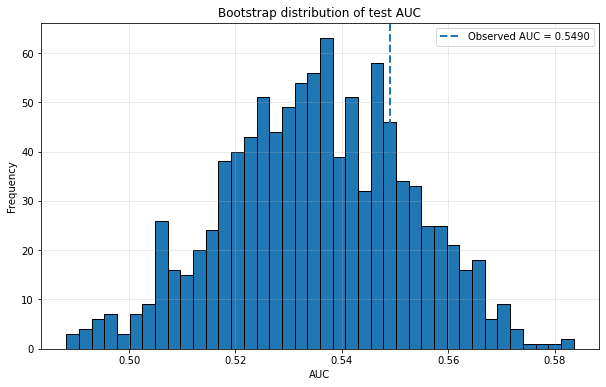

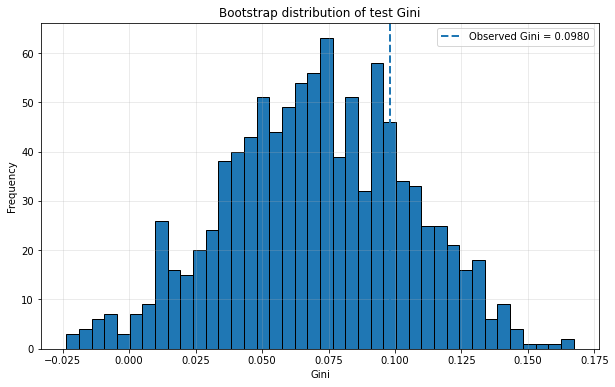

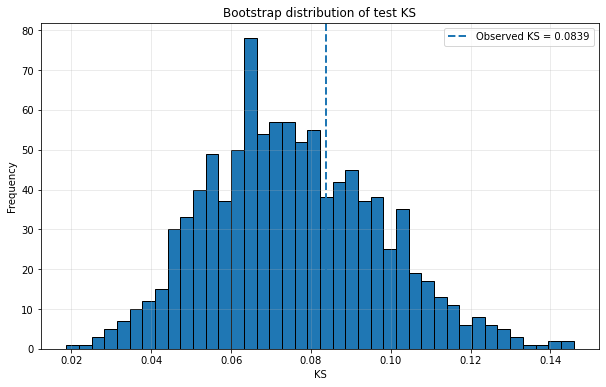


Bootstrap summary table
metric  observed_test  bootstrap_mean  bootstrap_std  bootstrap_p2_5  bootstrap_p97_5
   AUC       0.549023        0.535086       0.017222        0.501795         0.566589
  Gini       0.098045        0.070173       0.034444        0.003591         0.133177
    KS       0.083886        0.075531       0.021516        0.037105         0.120994


In [10]:
# =========================
# 14. Bootstrap training instability
# =========================
bootstrap_results = bootstrap_training_rows(
    train_df=train_df,
    test_df=test_df,
    feature_cols=feature_cols,
    n_bootstrap=1000,
    bootstrap_train_size=2000,
    random_state=RANDOM_STATE
)

if bootstrap_results.empty:
    raise ValueError("All bootstrap runs failed or were skipped.")

print("\nBootstrap results head")
print(bootstrap_results.head().to_string(index=False))

print(f"\nValid bootstrap runs: {len(bootstrap_results)} / {BOOTSTRAP_SAMPLES}")


# =========================
# 15. Summaries of bootstrap distributions
# =========================
summarize_bootstrap_metric(bootstrap_results["auc_test"].values, "AUC")
summarize_bootstrap_metric(bootstrap_results["gini_test"].values, "Gini")
summarize_bootstrap_metric(bootstrap_results["ks_test"].values, "KS")


# =========================
# 16. Bootstrap histograms
# =========================
plot_bootstrap_hist(
    metric_values=bootstrap_results["auc_test"].values,
    observed_value=test_auc,
    metric_name="AUC"
)

plot_bootstrap_hist(
    metric_values=bootstrap_results["gini_test"].values,
    observed_value=test_gini,
    metric_name="Gini"
)

plot_bootstrap_hist(
    metric_values=bootstrap_results["ks_test"].values,
    observed_value=test_ks,
    metric_name="KS"
)


# =========================
# 17. Compact bootstrap summary table
# =========================
bootstrap_summary_df = pd.DataFrame({
    "metric": ["AUC", "Gini", "KS"],
    "observed_test": [
        test_auc,
        test_gini,
        test_ks
    ],
    "bootstrap_mean": [
        bootstrap_results["auc_test"].mean(),
        bootstrap_results["gini_test"].mean(),
        bootstrap_results["ks_test"].mean()
    ],
    "bootstrap_std": [
        bootstrap_results["auc_test"].std(ddof=1),
        bootstrap_results["gini_test"].std(ddof=1),
        bootstrap_results["ks_test"].std(ddof=1)
    ],
    "bootstrap_p2_5": [
        np.percentile(bootstrap_results["auc_test"], 2.5),
        np.percentile(bootstrap_results["gini_test"], 2.5),
        np.percentile(bootstrap_results["ks_test"], 2.5)
    ],
    "bootstrap_p97_5": [
        np.percentile(bootstrap_results["auc_test"], 97.5),
        np.percentile(bootstrap_results["gini_test"], 97.5),
        np.percentile(bootstrap_results["ks_test"], 97.5)
    ]
})

print("\nBootstrap summary table")
print(bootstrap_summary_df.to_string(index=False))